In [10]:
from scipy.stats import norm
import numpy as np
import matplotlib.pyplot as plt

In [8]:
p_salem = 0.92
p_mayoub = 0.08

salem_dist = norm(loc=1000, scale=15)
mayoub_dist = norm(loc=940, scale=25)

In [14]:
X = np.linspace(850, 1050, 1000)

p_x_given_salem = salem_dist.pdf(X)
p_x_given_mayoub = mayoub_dist.pdf(X)

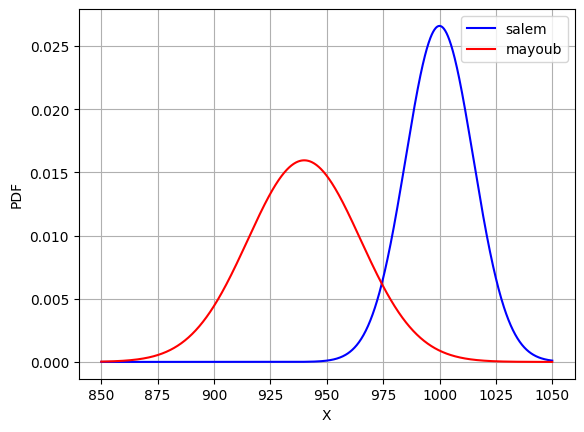

In [18]:
# The pdf's have some overlaps
plt.plot(X, p_x_given_salem, 'b', label="salem")
plt.plot(X, p_x_given_mayoub, 'r', label="mayoub")
plt.xlabel("X")
plt.ylabel("PDF")
plt.legend()
plt.grid()
plt.show()

In [32]:
X_test = 970
p_salem_given_x = p_salem * salem_dist.pdf(X_test) / (p_salem * salem_dist.pdf(X_test) + p_mayoub * mayoub_dist.pdf(X_test))
p_mayoub_given_x = p_mayoub * mayoub_dist.pdf(X_test) / (p_salem * salem_dist.pdf(X_test) + p_mayoub * mayoub_dist.pdf(X_test))

print("salem" if p_salem_given_x > p_mayoub_given_x else "mayoub")

salem


In [33]:
p_salem_given_x, p_mayoub_given_x

(np.float64(0.841998360712835), np.float64(0.15800163928716499))

In [38]:
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

In [45]:
X, y = load_wine(return_X_y=True)

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.3, random_state=42)
print(f"X_train.shape: {X_train.shape}")
print(f"X_test.shape: {X_test.shape}")
print(f"y_train.shape: {y_train.shape}")
print(f"y_test.shape: {y_test.shape}")

X_train.shape: (124, 13)
X_test.shape: (54, 13)
y_train.shape: (124,)
y_test.shape: (54,)


In [48]:
def train_knn(n_neighbors):
    knn = make_pipeline(
        StandardScaler(),
        KNeighborsClassifier(n_neighbors=n_neighbors)
    )
    knn.fit(X_train, y_train)
    train_score = knn.score(X_train, y_train)
    test_score = knn.score(X_test, y_test)
    print(f"train_score[k={n_neighbors}]: {train_score}")
    print(f"test_score[k={n_neighbors}]: {test_score}")

In [49]:
for k in [1, 5, 15]:
    train_knn(k)
    print("*" * 20)
    print()

train_score[k=1]: 1.0
test_score[k=1]: 0.9629629629629629
********************

train_score[k=5]: 0.9838709677419355
test_score[k=5]: 0.9444444444444444
********************

train_score[k=15]: 0.9758064516129032
test_score[k=15]: 0.9814814814814815
********************



با توجه به نتایج بالا مدل اول دچار بیش برازش است. چون با وجود دقت 1 در داده آموزش، دقت در داده آزمون پایین و مایوس کننده است.

مدل دوم نیز دقت آزمون دارای افت است با اینکه دقت آموزش خوب است. این مدل را نیز دارای بیش برازش میتوان در نظر گرفت.

در حالت سوم دو دقت با هم برابر هستند و میتوان گفت مدل تعمیم پدیر است